In [1]:

import os
import sys
# sys.path.append(os.path.dirname(os.path.dirname(__file__)))
sys.path.append('/home/scc_e_393956/ncc/rsa/')
from configs.config2 import * # directories + constants

import mne
import matplotlib

from utils import raw
from utils.ica import get_outFilePaths, get_blockwise_outFilePaths
from utils.subj import get_MEG_raw_subjects
import subprocess
from pathlib import Path

os.environ["MNE_BROWSER_BACKEND"] = "matplotlib"
mne.viz.set_browser_backend("matplotlib")

# %matplotlib widget
import matplotlib.pyplot as plt
import mne
%matplotlib widget
# mne.set_config("MNE_BROWSER_BACKEND", "matplotlib")
# mne.set_config("MNE_BROWSE_RAW_SIZE", "6,1")
# mne.set_config("MNE_BROWSE_RAW_SCALE", "0.5")

Using matplotlib as 2D backend.


open folder with rejected comp files no the side

In [2]:
# ica_folder = 'ica_qc_099cmp'
# ica_folder = 'ica_qc_095cmp'
ica_folder = 'ica_qc2'
# ica_folder = 'ica_qc_095_Infomax'
folder_rejectedComps = f'/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/step3_rejected_comps'
folder_topoPlots = f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/step3_comps_topos"
# folder_rejectedComps = f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/old_step3_rejected_comps"
# folder_topoPlots = f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/old_step3_comps_topos"

subprocess.Popen(["code", "--new-window", folder_rejectedComps])
subprocess.Popen(["code", "--new-window", folder_topoPlots])
plt.close('all')

In [3]:
# block-wise subjects
all_subjects = [
 '19970302urmr',
 '19910703eigl']

blockNames =  [	
				'block_01',
				'block_02',
				'block_03',
				'block_04',
				'block_05',
				'block_06',
				'block_07',
				'block_08',
				'block_09',
				'block_10',
				'block_11',
				'block_12',
	 ]

load data

## all_blocks

Opening raw data file /mnt/ceph/groups_hdd/SCCGroup/salzburg_brain_dynamics/reabt/ncc/MEG/mean_head_pos/ica_qc/step2_ica_tmp_data/19910703eigl_ica_data.fif...


/tmp/ipykernel_1484930/1186029774.py:11: RuntimeWarning: This filename (/mnt/ceph/groups_hdd/SCCGroup/salzburg_brain_dynamics/reabt/ncc/MEG/mean_head_pos/ica_qc/step2_ica_tmp_data/19910703eigl_ica_data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(rawFile, preload=False)


    Range : 78004 ... 1266704 =    390.020 ...  6333.520 secs
Ready.
Reading /mnt/ceph/groups_hdd/SCCGroup/salzburg_brain_dynamics/reabt/ncc/MEG/mean_head_pos/ica_qc/step2_ica_comps/19910703eigl_ica.fif ...
Now restoring ICA solution ...
Ready.
Creating RawArray with float64 data, n_channels=53, n_times=1188701
    Range : 78004 ... 1266704 =    390.020 ...  6333.520 secs
Ready.


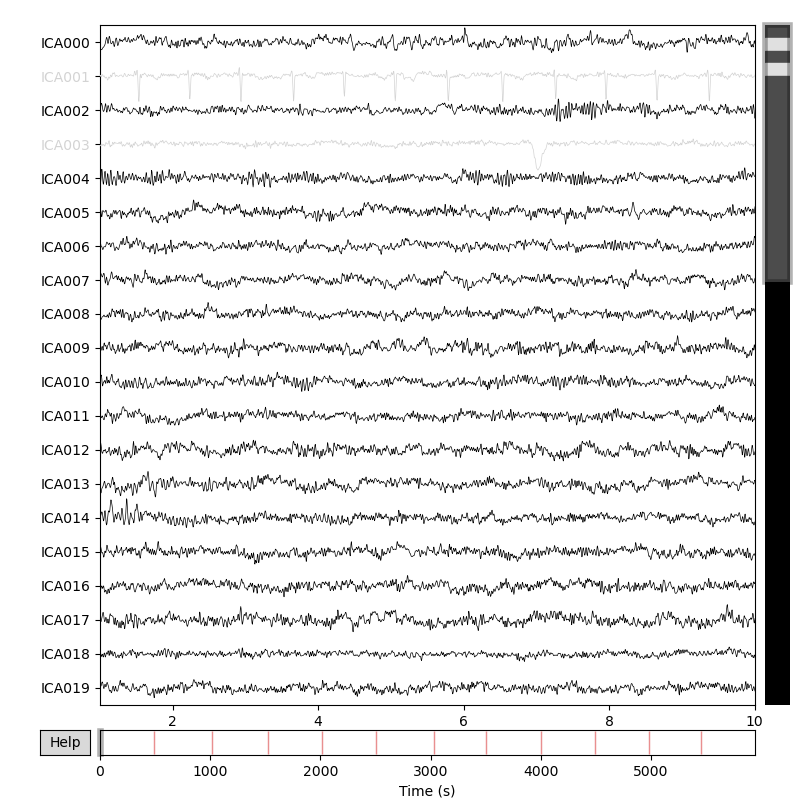

In [5]:

subjNr =1
blockNr = 1

plt.close('all')

blockNr = blockNr -1

rawFile = '/mnt/ceph/groups_hdd/SCCGroup/salzburg_brain_dynamics/reabt/ncc/MEG/mean_head_pos/ica_qc/step2_ica_tmp_data/19910703eigl_ica_data.fif'
icaFile = '/mnt/ceph/groups_hdd/SCCGroup/salzburg_brain_dynamics/reabt/ncc/MEG/mean_head_pos/ica_qc/step2_ica_comps/19910703eigl_ica.fif'

raw = mne.io.read_raw_fif(rawFile, preload=False)
ica = mne.preprocessing.read_ica(icaFile)
fig = ica.plot_sources(
    raw,
    show=True,
    block=False,
	overview_mode=False,
    start = 1,
    stop = 10,   
)


Effective window size : 2.000 (s)
Not setting metadata
2960 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
2960 matching events found
No baseline correction applied
0 projection items activated


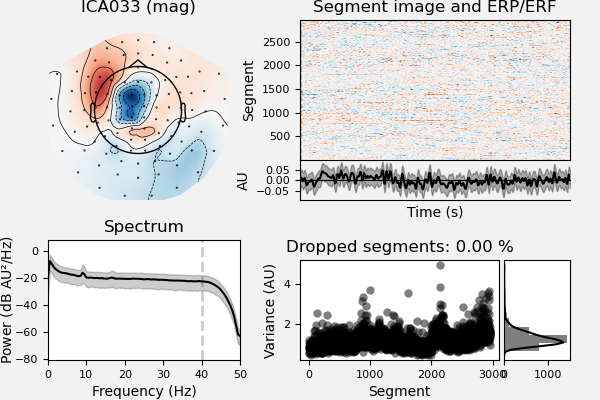

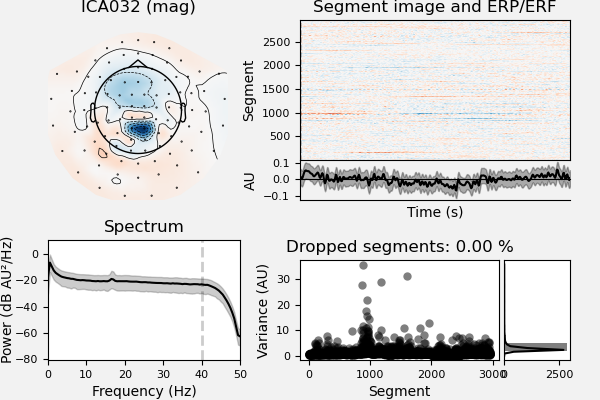

In [11]:
a = ica.plot_properties(
	raw, picks = [32, 33],
	figsize = (6, 4), psd_args={'method': 'welch'})

In [9]:
icaPaths

{'file_raw': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step1_raw_continuous/19910703eigl_raw.fif'),
 'file_ica': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step2_ica_comps/19910703eigl_ica.fif'),
 'file_icaData': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step2_ica_tmp_data/19910703eigl_ica_data.fif'),
 'file_rejected': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step3_rejected_comps/19910703eigl_ica_rejected_comps.json'),
 'file_topos': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step3_comps_topos/19910703eigl_ica_topos.png'),
 'file_metadata': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step4_ica_metadata/19910703eigl_ica_metadata.json'),
 'file_raw_clean': PosixPath('/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step5_raw_after_ica/19910703eigl_after-ica_raw.fif')}

## block-wise

In [ ]:

subjNr =0
blockNr = 1

plt.close('all')

blockNr = blockNr -1
# subject_id = all_subjects[all_subjects.index('19880331igse')]
# subject_id = all_subjects[30]
subject_id = all_subjects[subjNr]
# subject_id = '19951227eipo'
print(f"Subject ID: {subject_id}")

# _, icaPaths = get_outFilePaths(subject_id, out_root="/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc")
# _, icaPaths = get_outFilePaths(subject_id, out_root=f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}")
# rawFile = icaPaths[blocks[0]]['file_icaData']
# icaFile = icaPaths[blocks[0]]['file_ica']


_, icaPaths = get_blockwise_outFilePaths(subject_id, out_root=f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}", block_indices=[blockNr+1])
icaPaths['blocks'][blockNames[blockNr]]

rawFile = icaPaths['blocks'][blockNames[blockNr]]['file_icaData']
icaFile = icaPaths['blocks'][blockNames[blockNr]]['file_ica']

# rawFile = f'/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc_blockwise/step1_raw_continuous/{subject_id}_block_00_raw.fif'

raw = mne.io.read_raw_fif(rawFile, preload=False)
ica = mne.preprocessing.read_ica(icaFile)
# raw = raw.filter(l_freq = None , h_freq=40.0, n_jobs=-1)
fig = ica.plot_sources(
    raw,
    show=True,
    block=False,
	# overview_mode=False,
    start = 1,
    stop = 10,   
)


In [ ]:
a = ica.plot_properties(
	raw, picks = [7],
	figsize = (6, 4), psd_args={'method': 'welch'})


In [ ]:

# a = ica.plot_properties(
# 	raw, picks = range(31, 50),
# 	figsize = (6, 4), psd_args={'method': 'welch'})


In [ ]:
comp = [35, 37, 39, 40 , 46]
ica.get_explained_variance_ratio(raw.load_data(), components = comp)